In [1]:
# Dependencies already installed in the 'brats' conda environment
# If needed, run: pip install segmentation-models-pytorch albumentations nibabel pandas matplotlib tqdm ipykernel

In [2]:
import segmentation_models_pytorch as smp
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import time
import albumentations as A
import torch.nn.functional as F
import pandas as pd
import h5py
from tqdm import tqdm

c:\Users\bhmed\anaconda3\envs\brats\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Configuration and reproducibility
def set_seed(seed=42):
    import random
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f'Seed set to {seed}; cudnn.deterministic=True, benchmark=False (may be slower)')

# Central config dictionary (paths, sizes, modalities, seeds, hyperparams)
CFG = {
    'seed': 42,
    'data_dir': 'BraTS2020_training_data/content/data',
    'crop_size': 128,
    'et_crop_size': 160,
    'modalities': ['t1', 't1ce', 't2', 'flair'],
    'batch_size': 8,
    'lr': 1e-3,
    'epochs_stageA': 10,
    'epochs_stageB': 10,
    'device': torch.device('cuda:0' if torch.cuda.is_available() else 'cpu'),
}

# Apply seed for reproducibility
set_seed(CFG['seed'])

Seed set to 42; cudnn.deterministic=True, benchmark=False (may be slower)


In [4]:
DATA_ZIP_PATH = r'./BraTS.zip'

# Extract dataset

In [5]:
import zipfile

if not os.path.exists('BraTS2020_training_data'):
    with zipfile.ZipFile(DATA_ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall('.')
    print('Dataset extracted.')
else:
    print('Dataset folder already exists, skipping extraction.')

Dataset folder already exists, skipping extraction.


In [6]:
DATA_DIR = 'BraTS2020_training_data/content/data'
h5_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.h5')])
print(f'Total H5 slices: {len(h5_files)}')
print(f'First 5 files: {h5_files[:5]}')

Total H5 slices: 57195
First 5 files: ['volume_100_slice_0.h5', 'volume_100_slice_1.h5', 'volume_100_slice_10.h5', 'volume_100_slice_100.h5', 'volume_100_slice_101.h5']


In [7]:
# Inspect H5 file structure
with h5py.File(os.path.join(DATA_DIR, h5_files[100]), 'r') as f:
    img = f['image'][:]
    mask = f['mask'][:]
    print(f'Image: shape={img.shape}, dtype={img.dtype}')
    print(f'Mask:  shape={mask.shape}, dtype={mask.dtype}')
    print(f'Image range: [{img.min():.4f}, {img.max():.4f}]')
    print(f'Mask unique values per channel:')
    for ch in range(mask.shape[2]):
        print(f'  Ch{ch}: {np.unique(mask[:,:,ch])}')

Image: shape=(240, 240, 4), dtype=float64
Mask:  shape=(240, 240, 3), dtype=uint8
Image range: [-0.0734, 29.9245]
Mask unique values per channel:
  Ch0: [0]
  Ch1: [0]
  Ch2: [0]


In [8]:
# Read name mapping
data = pd.read_csv(os.path.join(DATA_DIR, 'name_mapping.csv'))
data.head(5)

,Grade,BraTS_2017_subject_ID,BraTS_2018_subject_ID,TCGA_TCIA_subject_ID,BraTS_2019_subject_ID,BraTS_2020_subject_ID
0,HGG,Brats17_CBICA_AAB_1,Brats18_CBICA_AAB_1,NaN,BraTS19_CBICA_AAB_1,BraTS20_Training_001
1,HGG,Brats17_CBICA_AAG_1,Brats18_CBICA_AAG_1,NaN,BraTS19_CBICA_AAG_1,BraTS20_Training_002
2,HGG,Brats17_CBICA_AAL_1,Brats18_CBICA_AAL_1,NaN,BraTS19_CBICA_AAL_1,BraTS20_Training_003
3,HGG,Brats17_CBICA_AAP_1,Brats18_CBICA_AAP_1,NaN,BraTS19_CBICA_AAP_1,BraTS20_Training_004
4,HGG,Brats17_CBICA_ABB_1,Brats18_CBICA_ABB_1,NaN,BraTS19_CBICA_ABB_1,BraTS20_Training_005


In [9]:
# Get unique patient volumes and slice counts
volumes = set()
for f in h5_files:
    # filename format: volume_{id}_slice_{num}.h5
    parts = f.replace('.h5', '').split('_slice_')
    volumes.add(parts[0])
print(f'Unique patient volumes: {len(volumes)}')
print(f'Total slices: {len(h5_files)}')

Unique patient volumes: 369
Total slices: 57195


In [10]:
def cropcentre(arr, cropx, cropy):
    y, x = arr.shape[:2]
    startx = x // 2 - (cropx // 2)
    starty = y // 2 - (cropy // 2)
    if arr.ndim == 3:
        return arr[starty:starty+cropy, startx:startx+cropx, :]
    return arr[starty:starty+cropy, startx:startx+cropx]

In [11]:
# Filter to keep only slices that contain tumor (mask > 0)
tumor_files = []
for f in tqdm(h5_files, desc='Filtering tumor slices'):
    with h5py.File(os.path.join(DATA_DIR, f), 'r') as hf:
        mask = hf['mask'][:]
        if mask.max() > 0:
            tumor_files.append(f)
print(f'Slices with tumor: {len(tumor_files)} / {len(h5_files)}')

Filtering tumor slices: 100%|██████████| 57195/57195 [04:08<00:00, 230.49it/s]

Slices with tumor: 24422 / 57195


In [12]:
# Save filtered file list for the Dataset class
# Use tumor_files so we only train on slices with actual segmentation labels
print(f'Using {len(tumor_files)} slices with tumor content')

Using 24422 slices with tumor content


In [13]:
total_size = sum(os.path.getsize(os.path.join(DATA_DIR, f)) for f in h5_files)
print(f'Dataset size: {total_size / (1024*1024):.1f} MB')

Dataset size: 7579.8 MB


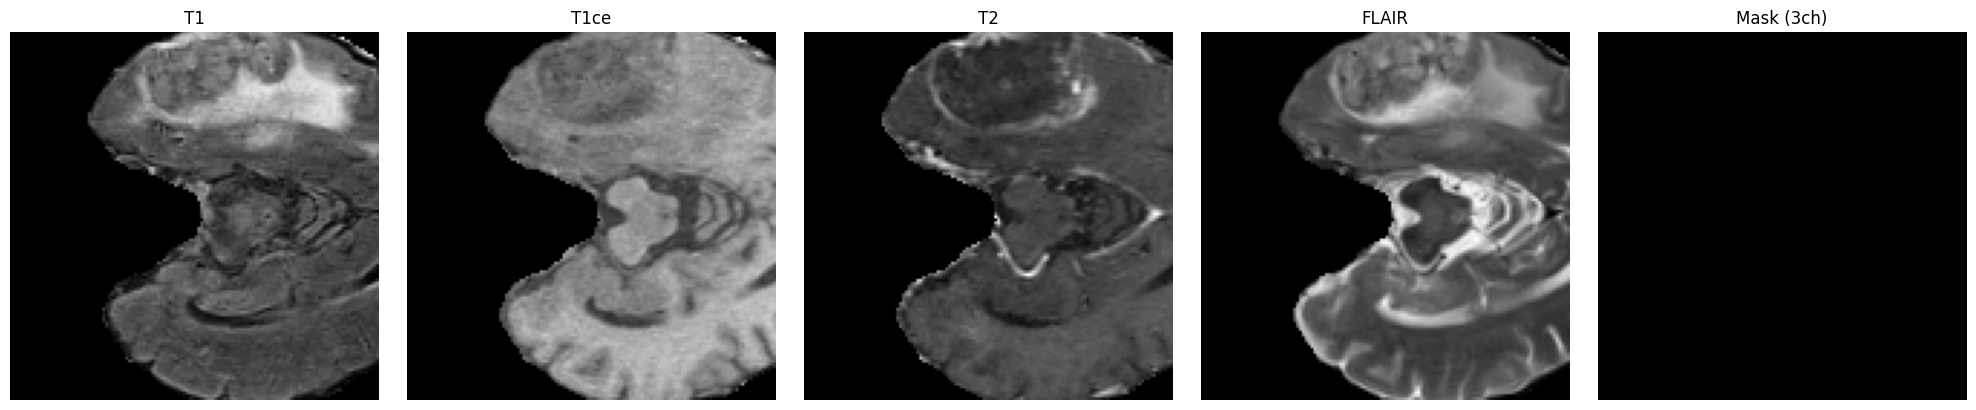

In [14]:
# Preview a sample with tumor
with h5py.File(os.path.join(DATA_DIR, tumor_files[25]), 'r') as f:
    img = f['image'][:]
    mask = f['mask'][:]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
titles = ['T1', 'T1ce', 'T2', 'FLAIR', 'Mask']
for i in range(4):
    axes[i].imshow(cropcentre(img[:,:,i], 128, 128), cmap='gray')
    axes[i].set_title(titles[i])
    axes[i].axis('off')
# Show mask as composite of 3 channels
axes[4].imshow(cropcentre(mask, 128, 128))
axes[4].set_title('Mask (3ch)')
axes[4].axis('off')
plt.tight_layout()

# Inspect mask channels and determine ET channel

Add a helper `summarize_mask_channels(file_list, n=30)` that samples tumor slices, visualizes `FLAIR`, `T1ce`, and the three mask channels,
prints per-channel pixel counts, and suggests which mask channel best matches Enhancing Tumor (ET).

It also provides `get_ET_mask(mask, et_channel)` to derive an ET boolean mask from multi-channel or single-label masks.

In [15]:
import random
from collections import defaultdict

def summarize_mask_channels(file_list, n=30, data_dir=DATA_DIR, crop_size=128, random_seed=42):
    """Sample `n` files from `file_list`, visualize FLAIR, T1ce and the 3 mask channels,
    and print per-channel pixel counts. Returns a summary dict with per-channel stats."""
    rng = random.Random(random_seed)
    sample_files = rng.sample(file_list, min(n, len(file_list)))

    per_channel_counts = defaultdict(list)
    per_channel_mean_t1ce = defaultdict(list)

    rows = len(sample_files)
    cols = 5  # FLAIR, T1ce, mask0, mask1, mask2
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, max(3, rows * 2)))
    if rows == 1:
        axes = axes.reshape(1, -1)

    for i, fname in enumerate(sample_files):
        with h5py.File(os.path.join(data_dir, fname), 'r') as f:
            img = cropcentre(f['image'][:], crop_size, crop_size)
            mask = cropcentre(f['mask'][:], crop_size, crop_size)

        # image channels: 0:T1, 1:T1ce, 2:T2, 3:FLAIR
        t1 = img[:, :, 0]
        t1ce = img[:, :, 1]
        flair = img[:, :, 3]

        axes[i, 0].imshow(flair, cmap='gray')
        axes[i, 0].set_title(f'{fname}\nFLAIR')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(t1ce, cmap='gray')
        axes[i, 1].set_title('T1ce')
        axes[i, 1].axis('off')

        # Normalize mask shape: if single-channel labeled mask, derive 3 channels approximation
        if mask.ndim == 2:
            single = mask
            # Typical BraTS single-label values: 0 background, 1 necrotic/cystic, 2 edema, 3 non-enhancing tumor?, 4 enhancing tumor
            mchs = [ (single==4).astype(np.uint8), (single==1).astype(np.uint8), ((single==2)|(single==3)).astype(np.uint8) ]
            m = np.stack(mchs, axis=2)
        else:
            m = mask

        for ch in range(min(3, m.shape[2])):
            mch = m[:, :, ch] > 0
            per_channel_counts[ch].append(int(mch.sum()))
            if mch.sum() > 0:
                per_channel_mean_t1ce[ch].append(float(t1ce[mch].mean()))
            else:
                per_channel_mean_t1ce[ch].append(0.0)

            axes[i, 2 + ch].imshow(mch, cmap='gray')
            axes[i, 2 + ch].set_title(f'Mask ch{ch}\ncount={per_channel_counts[ch][-1]}')
            axes[i, 2 + ch].axis('off')

    plt.tight_layout()
    plt.show()

    summary = {}
    for ch in sorted(per_channel_counts.keys()):
        counts = np.array(per_channel_counts[ch])
        means = np.array(per_channel_mean_t1ce[ch])
        summary[ch] = {
            'samples_nonzero': int((counts > 0).sum()),
            'median_count': float(np.median(counts)),
            'mean_t1ce_in_mask': float(means.mean())
        }

    best_ch = max(summary.keys(), key=lambda c: summary[c]['mean_t1ce_in_mask']) if summary else None
    print('\nChannel summary (per-channel):')
    for ch, v in summary.items():
        print(f'  ch{ch}: samples_nonzero={v["samples_nonzero"]}  median_count={v["median_count"]:.1f}  mean_T1ce_in_mask={v["mean_t1ce_in_mask"]:.3f}')
    print(f'\nBest candidate ET channel: ch{best_ch} (highest mean T1ce inside mask)')

    return {'summary': summary, 'best_ch': best_ch, 'per_channel_counts': per_channel_counts, 'per_channel_mean_t1ce': per_channel_mean_t1ce}

In [16]:
def get_ET_mask(mask, et_channel=None):
    """Return a boolean ET mask. If `mask` has multiple channels (H,W,3) and `et_channel` is provided, returns that channel. If `mask` is single-channel with BraTS labels (0..4), returns (mask==4)."""
    if mask.ndim == 3 and mask.shape[2] >= 1:
        if et_channel is None:
            raise ValueError('et_channel must be provided for multi-channel masks')
        return (mask[:, :, et_channel] > 0).astype(np.uint8)
    else:
        return (mask == 4).astype(np.uint8)

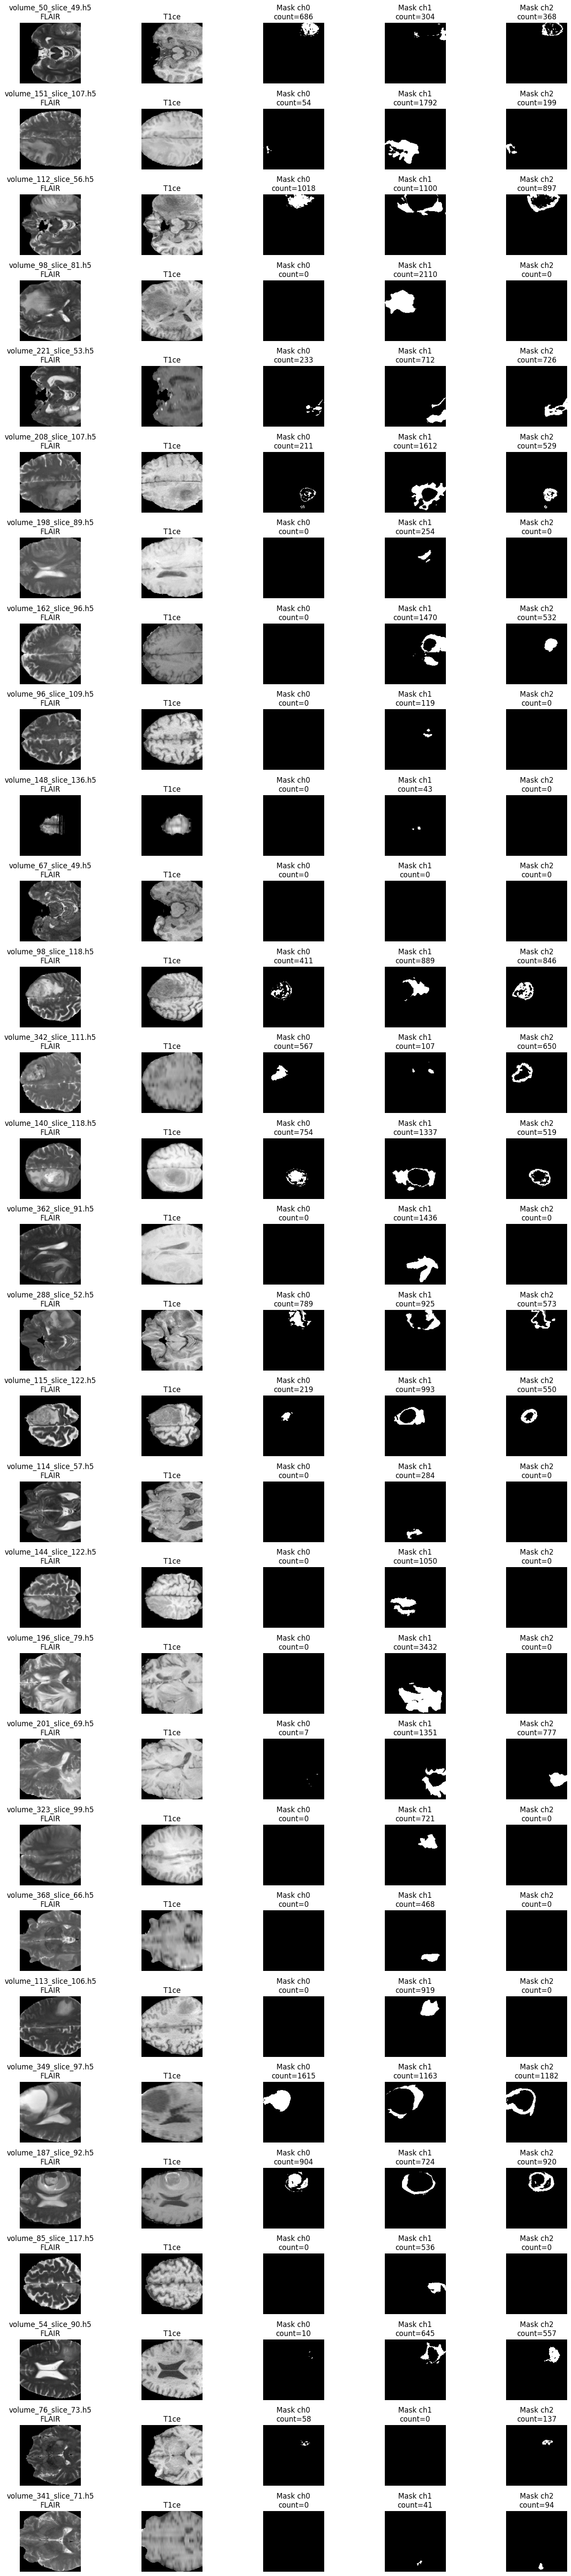


Channel summary (per-channel):
  ch0: samples_nonzero=15  median_count=3.5  mean_T1ce_in_mask=0.767
  ch1: samples_nonzero=28  median_count=806.5  mean_T1ce_in_mask=1.844
  ch2: samples_nonzero=17  median_count=168.0  mean_T1ce_in_mask=0.928

Best candidate ET channel: ch1 (highest mean T1ce inside mask)

Inferred ET channel: ch1


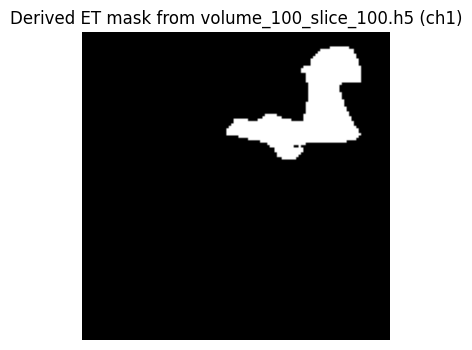

In [17]:
# Run summarizer and set ET_CH
res = summarize_mask_channels(tumor_files, n=30)
ET_CH = res['best_ch']
print(f'\nInferred ET channel: ch{ET_CH}')
# Demonstrate deriving ET mask for first sample
with h5py.File(os.path.join(DATA_DIR, tumor_files[0]), 'r') as f:
    m0 = cropcentre(f['mask'][:], 128, 128)
et_demo = get_ET_mask(m0, et_channel=ET_CH) if ET_CH is not None else get_ET_mask(m0)
plt.figure(figsize=(4,4))
plt.imshow(et_demo, cmap='gray')
plt.title(f'Derived ET mask from {tumor_files[0]} (ch{ET_CH})')
plt.axis('off')
plt.show()

# Dataset

In [18]:
def normalize_modality(arr, brain_mask, pct_clip=None, eps=1e-8):
    """Clip (optional) and z-score normalize `arr` using only `brain_mask` pixels."""
    a = arr.astype(np.float32).copy()
    mask_idx = brain_mask.astype(bool)
    if pct_clip is not None and mask_idx.sum() > 0:
        lo, hi = np.percentile(a[mask_idx], pct_clip)
        a = np.clip(a, lo, hi)
    if mask_idx.sum() > 0:
        m = a[mask_idx].mean()
        s = a[mask_idx].std()
    else:
        m = a.mean(); s = a.std()
    if np.isfinite(s) and s > 0:
        a = (a - m) / (s + eps)
    else:
        a = a - m
    return a

class BraTSDataset(Dataset):
    def __init__(self, file_list, data_dir, crop_size=128, augmentation=None, input_modalities=None, percentile_clip=None, debug=False, task=None, et_channel=None):
        """file_list: list of h5 filenames (slices).
        input_modalities: list of modalities to use, choices: ['t1','t1ce','t2','flair'] (default all 4).
        percentile_clip: tuple (low_pct, high_pct) e.g. (0.5, 99.5) or None.
        task: None (legacy multi-class), 'wt' or 'et' to return binary masks for those tasks.
        et_channel: when mask is multi-channel, which channel corresponds to ET (int).
        """
        self.file_list = file_list
        self.data_dir = data_dir
        self.crop_size = crop_size
        self.augmentation = augmentation
        self.percentile_clip = percentile_clip
        self.debug = debug
        self.task = task
        self.et_channel = et_channel
        if input_modalities is None:
            self.input_modalities = ['t1','t1ce','t2','flair']
        else:
            self.input_modalities = input_modalities
        # modality -> channel index in the H5 image array
        self._mod_idx = {'t1':0, 't1ce':1, 't2':2, 'flair':3}

    def __getitem__(self, idx):
        with h5py.File(os.path.join(self.data_dir, self.file_list[idx]), 'r') as f:
            image = f['image'][:]  # (H, W, 4)
            mask = f['mask'][:]    # (H, W, 3) or (H,W) single-label

        # Center crop
        image = cropcentre(image, self.crop_size, self.crop_size)
        mask = cropcentre(mask, self.crop_size, self.crop_size)

        # Extract modality arrays
        t1 = image[:, :, 0]
        t1ce = image[:, :, 1]
        t2 = image[:, :, 2]
        flair = image[:, :, 3]

        # Apply augmentation (keeps same API as before) if provided
        if self.augmentation:
            augmented = self.augmentation(image=flair, mask=mask, t1=t1, t1ce=t1ce, t2=t2)
            flair = augmented['image']
            mask = augmented['mask']
            t1 = augmented['t1']
            t1ce = augmented['t1ce']
            t2 = augmented['t2']

        # Build brain mask (non-zero pixels across modalities)
        stacked = np.stack([t1, t1ce, t2, flair], axis=2)
        brain_mask = (np.abs(stacked).sum(axis=2) > 0)

        # Optional: print before stats for first few samples if debug
        if self.debug and idx < 3:
            print(f'Before normalization (sample {idx}):')
            for name, arr in [('t1', t1), ('t1ce', t1ce), ('t2', t2), ('flair', flair)]:
                vals = arr[brain_mask]
                if vals.size>0:
                    print(f'  {name}: min={vals.min():.3f} max={vals.max():.3f} mean={vals.mean():.3f} std={vals.std():.3f}')
                else:
                    print(f'  {name}: EMPTY')

        # Normalize selected modalities
        modality_arrays = {'t1':t1, 't1ce':t1ce, 't2':t2, 'flair':flair}
        normed = []
        for m in self.input_modalities:
            arr = modality_arrays[m]
            arr_n = normalize_modality(arr, brain_mask, pct_clip=self.percentile_clip)
            normed.append(arr_n)

        # Optional: print after stats
        if self.debug and idx < 3:
            print(f'After normalization (sample {idx}):')
            for name, arr in zip(self.input_modalities, normed):
                vals = arr[brain_mask]
                if vals.size>0:
                    print(f'  {name}: min={vals.min():.3f} max={vals.max():.3f} mean={vals.mean():.3f} std={vals.std():.3f}')
                else:
                    print(f'  {name}: EMPTY')

        # Stack selected modalities to channels-first tensor
        input_tensor = torch.from_numpy(np.stack(normed, axis=0)).float()

        # Process mask depending on task
        mask = mask.astype(np.float32)
        if self.task == 'wt':
            # return binary WT mask (1,H,W)
            if mask.ndim == 3:
                wt = (mask.sum(axis=2) > 0).astype(np.float32)
            else:
                wt = (mask > 0).astype(np.float32)
            mask_tensor = torch.from_numpy(wt[None, ...]).float()
            return input_tensor, mask_tensor
        elif self.task == 'et':
            # return binary ET mask (1,H,W)
            if mask.ndim == 3:
                et = (mask[:, :, self.et_channel] > 0).astype(np.float32) if self.et_channel is not None else (mask.sum(axis=2) > 0).astype(np.float32)
            else:
                et = (mask == 4).astype(np.float32)
            mask_tensor = torch.from_numpy(et[None, ...]).float()
            return input_tensor, mask_tensor
        else:
            # default: keep legacy 4-channel (background + 3) representation
            if mask.ndim == 2:
                bg = (mask == 0).astype(np.float32)[..., None]
                ch0 = (mask == 4).astype(np.float32)[..., None]
                ch1 = (mask == 1).astype(np.float32)[..., None]
                ch2 = ((mask == 2) | (mask == 3)).astype(np.float32)[..., None]
                mask_4ch = np.concatenate([bg, ch0, ch1, ch2], axis=2)
            else:
                bg = 1.0 - np.clip(mask.sum(axis=2, keepdims=True), 0, 1)
                mask_4ch = np.concatenate([bg, mask], axis=2)
            mask_tensor = torch.from_numpy(mask_4ch).permute(2, 0, 1).long()
            return input_tensor, mask_tensor

    def __len__(self):
        return len(self.file_list)


In [ ]:
# Augmentations
augmentation = A.Compose([
    A.OneOf([
        A.ElasticTransform(alpha=120, sigma=120 * 0.05, p=0.5),
        A.GridDistortion(p=0.5),
        A.OpticalDistortion(distort_limit=2, p=0.5)
    ], p=0.8),
    A.RandomBrightnessContrast(p=0.8),
], additional_targets={'t1':'image', 't1ce':'image', 't2':'image'})

# Helpers: volume id parsing and splitting by volume (patient-level) to avoid data leakage
def get_volume_id(filename):
    # filename format: volume_{id}_slice_{num}.h5 -> return 'volume_{id}'
    return filename.split('_slice_')[0]

import random
def split_by_volume(file_list, seed=42, ratios=(0.6, 0.2, 0.2)):
    rng = random.Random(seed)
    volume_ids = sorted(set(get_volume_id(f) for f in file_list))
    rng.shuffle(volume_ids)
    n = len(volume_ids)
    n_train = int(ratios[0] * n)
    n_val = int(ratios[1] * n)
    train_vols = set(volume_ids[:n_train])
    val_vols = set(volume_ids[n_train:n_train + n_val])
    test_vols = set(volume_ids[n_train + n_val:])

    def files_for(volset):
        return [f for f in file_list if get_volume_id(f) in volset]

    train_files = files_for(train_vols)
    val_files = files_for(val_vols)
    test_files = files_for(test_vols)
    return (train_vols, val_vols, test_vols, train_files, val_files, test_files)

# Split tumor_files by volume (60/20/20) with seed=42
train_vols, val_vols, test_vols, train_files, val_files, test_files = split_by_volume(tumor_files, seed=42)

# Quick sanity checks and counts (volumes, slices, ET-positive slices).
def _is_et_positive(fname):
    with h5py.File(os.path.join(DATA_DIR, fname), 'r') as f:
        m = cropcentre(f['mask'][:], 128, 128)
        if m.ndim == 2:
            return bool((m == 4).any())
        else:
            # If ET_CH was inferred earlier, use it; otherwise we cannot reliably detect ET channel here
            if 'ET_CH' in globals() and ET_CH is not None:
                return bool((m[:, :, ET_CH] > 0).any())
            else:
                return False

def print_split_stats(name, volset, files):
    vols = sorted(set(get_volume_id(f) for f in files))
    slices = len(files)
    et_pos = sum(1 for f in files if _is_et_positive(f))
    print(f'{name}: #volumes={len(vols)}  #slices={slices}  #ET-positive_slices={et_pos}')

print_split_stats('TRAIN', train_vols, train_files)
print_split_stats('VAL', val_vols, val_files)
print_split_stats('TEST', test_vols, test_files)

# Build Dataset objects from the per-volume splits
train_dataset = BraTSDataset(file_list=train_files, data_dir=DATA_DIR, augmentation=augmentation)
valid_dataset = BraTSDataset(file_list=val_files, data_dir=DATA_DIR, augmentation=None)
test_dataset = BraTSDataset(file_list=test_files, data_dir=DATA_DIR, augmentation=None)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=1, num_workers=0, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=1, num_workers=0, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, num_workers=0, shuffle=False)

C:\Users\bhmed\AppData\Local\Temp\ipykernel_872\2158173428.py:4: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03, p=0.5),
C:\Users\bhmed\AppData\Local\Temp\ipykernel_872\2158173428.py:6: UserWarning: Argument(s) 'shift_limit' are not valid for transform OpticalDistortion
  A.OpticalDistortion(distort_limit=2, shift_limit=0.5, p=0.5)


TRAIN: #volumes=221  #slices=14482  #ET-positive_slices=14328
VAL: #volumes=73  #slices=4979  #ET-positive_slices=4837
TEST: #volumes=75  #slices=4961  #ET-positive_slices=4888


In [20]:
a,b=next(iter(train_loader))

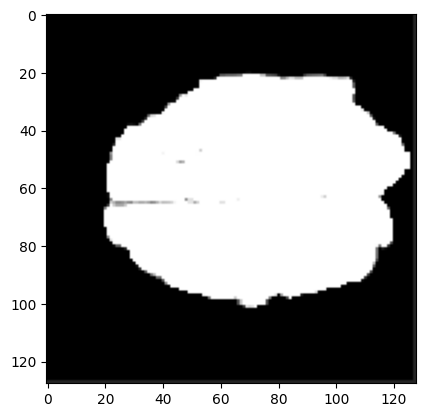

In [21]:
plt.imshow(a[0,0],cmap='gray')

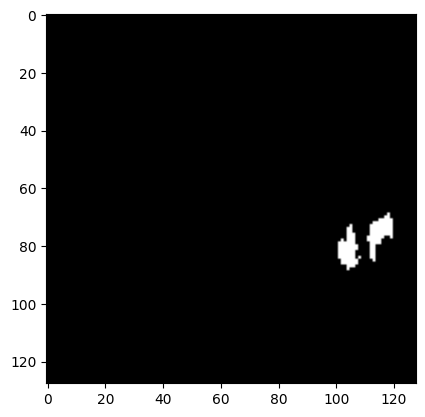

In [22]:
bb = torch.argmax(b,1)
plt.imshow(bb[0],cmap='gray')

# Stage A: Whole-Tumor (WT) localization

This section implements a lightweight Stage-A pipeline that predicts a coarse Whole-Tumor (WT) binary mask from full slices.
Deliverables: a `BraTSDatasetWT` dataset (mode `task='wt'` equivalent), `bbox_from_mask`, `crop_to_bbox`, a `resnet18`-encoder U-Net, and a training loop that saves `model_wt.pth`.

Notes: training uses combined Dice (binary) + BCEWithLogits loss for stability. The dataset for Stage A uses all slices (including background-only).

In [23]:
def bbox_from_mask(mask, margin=16):
    """Compute bounding box (x1,y1,x2,y2) of non-zero `mask` with a pixel `margin`."""
    m = (mask > 0).astype(np.uint8)
    if m.sum() == 0:
        # return central box if empty
        h, w = mask.shape[:2]
        cx, cy = w // 2, h // 2
        half = max(16, margin)
        x1 = max(0, cx - half); y1 = max(0, cy - half)
        x2 = min(w, cx + half); y2 = min(h, cy + half)
        return x1, y1, x2, y2
    ys, xs = np.where(m > 0)
    y1 = max(0, ys.min() - margin)
    y2 = min(mask.shape[0], ys.max() + margin + 1)
    x1 = max(0, xs.min() - margin)
    x2 = min(mask.shape[1], xs.max() + margin + 1)
    return x1, y1, x2, y2

def crop_to_bbox(image, bbox, out_size=(160, 160)):
    """Crop `image` (H,W,...) to `bbox`=(x1,y1,x2,y2) and pad/resize to `out_size`."""
    x1, y1, x2, y2 = bbox
    crop = image[y1:y2, x1:x2].copy()
    h, w = crop.shape[:2]
    oh, ow = out_size
    # Pad to square with zeros centered
    pad_h = max(0, oh - h)
    pad_w = max(0, ow - w)
    pad_top = pad_h // 2; pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2; pad_right = pad_w - pad_left
    if crop.ndim == 2:
        crop_padded = np.pad(crop, ((pad_top, pad_bottom), (pad_left, pad_right)), mode='constant')
    else:
        crop_padded = np.pad(crop, ((pad_top, pad_bottom), (pad_left, pad_right), (0,0)), mode='constant')
    # If larger than out_size, center-crop
    ch, cw = crop_padded.shape[:2]
    start_y = max(0, (ch - oh) // 2)
    start_x = max(0, (cw - ow) // 2)
    result = crop_padded[start_y:start_y+oh, start_x:start_x+ow]
    return result

In [24]:
class BraTSDatasetWT(Dataset):
    """Dataset for Stage-A WT localization. Returns input tensor and binary WT mask (1,H,W)."""
    def __init__(self, file_list, data_dir, crop_size=128, augmentation=None, input_modalities=None, percentile_clip=None, debug=False):
        self.file_list = file_list
        self.data_dir = data_dir
        self.crop_size = crop_size
        self.augmentation = augmentation
        self.percentile_clip = percentile_clip
        self.debug = debug
        if input_modalities is None:
            self.input_modalities = ['t1','t1ce','t2','flair']
        else:
            self.input_modalities = input_modalities
        self._mod_idx = {'t1':0, 't1ce':1, 't2':2, 'flair':3}

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        with h5py.File(os.path.join(self.data_dir, self.file_list[idx]), 'r') as f:
            image = f['image'][:]  # (H,W,4)
            mask = f['mask'][:]
        image = cropcentre(image, self.crop_size, self.crop_size)
        mask = cropcentre(mask, self.crop_size, self.crop_size)
        # compute WT binary mask: union of any tumor channel (>0) or single-label >0
        if mask.ndim == 3:
            wt = (mask.sum(axis=2) > 0).astype(np.uint8)
        else:
            wt = (mask > 0).astype(np.uint8)
        # modalities
        t1 = image[:,:,0]; t1ce = image[:,:,1]; t2 = image[:,:,2]; flair = image[:,:,3]
        modality_arrays = {'t1':t1, 't1ce':t1ce, 't2':t2, 'flair':flair}
        stacked = np.stack([t1,t1ce,t2,flair], axis=2)
        brain_mask = (np.abs(stacked).sum(axis=2) > 0)
        normed = []
        for m in self.input_modalities:
            arr = modality_arrays[m]
            arr_n = normalize_modality(arr, brain_mask, pct_clip=self.percentile_clip)
            normed.append(arr_n)
        input_tensor = torch.from_numpy(np.stack(normed, axis=0)).float()
        wt_tensor = torch.from_numpy(wt.astype(np.float32))[None, ...]
        return input_tensor, wt_tensor

In [25]:
class BraTSDatasetET(Dataset):
    """Dataset for Stage-B ET segmentation. Returns cropped input tensor and ET binary mask (1,H,W).
    If `use_gt_wt` is True, compute bounding box from GT mask; otherwise expects full-slice inputs and returns full-size crops.
    """
    def __init__(self, file_list, data_dir, crop_size=160, use_gt_wt=True, input_modalities=None, percentile_clip=None, et_channel=None, debug=False):
        self.file_list = file_list
        self.data_dir = data_dir
        self.crop_size = crop_size
        self.use_gt_wt = use_gt_wt
        self.input_modalities = input_modalities or ['t1ce']
        self.percentile_clip = percentile_clip
        self.et_channel = et_channel
        self.debug = debug
        self._mod_idx = {'t1':0, 't1ce':1, 't2':2, 'flair':3}

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        fname = self.file_list[idx]
        with h5py.File(os.path.join(self.data_dir, fname), 'r') as f:
            image = f['image'][:]  # H,W,4
            mask = f['mask'][:]

        # compute bbox from GT WT (union of channels) if requested
        if self.use_gt_wt:
            if mask.ndim == 3:
                wt = (mask.sum(axis=2) > 0).astype(np.uint8)
            else:
                wt = (mask > 0).astype(np.uint8)
            bbox = bbox_from_mask(wt)
        else:
            # fallback to central bbox
            bbox = bbox_from_mask(np.zeros_like(image[...,0]))

        # crop image and mask to bbox and pad/resize to crop_size
        img_crop = crop_to_bbox(image[..., :], bbox, out_size=(self.crop_size, self.crop_size))
        if mask.ndim == 3:
            et_mask = get_ET_mask(crop_to_bbox(mask, bbox, out_size=(self.crop_size, self.crop_size)), et_channel=(self.et_channel if self.et_channel is not None else ET_CH))
        else:
            et_mask = get_ET_mask(crop_to_bbox(mask, bbox, out_size=(self.crop_size, self.crop_size)))

        # select modalities and normalize per-modality
        modality_arrays = {'t1':img_crop[:,:,0], 't1ce':img_crop[:,:,1], 't2':img_crop[:,:,2], 'flair':img_crop[:,:,3]}
        stacked = np.stack([modality_arrays[m] for m in ['t1','t1ce','t2','flair']], axis=2)
        brain_mask = (np.abs(stacked).sum(axis=2) > 0)
        normed = []
        for m in self.input_modalities:
            arr = modality_arrays[m]
            arr_n = normalize_modality(arr, brain_mask, pct_clip=self.percentile_clip)
            normed.append(arr_n)
        input_tensor = torch.from_numpy(np.stack(normed, axis=0)).float()
        et_tensor = torch.from_numpy(et_mask.astype(np.float32))[None, ...].float()
        return input_tensor, et_tensor

In [26]:
# Build Stage-B datasets (ET) using GT WT cropping for ROI extraction by default
train_et_ds = BraTSDatasetET(file_list=train_files, data_dir=DATA_DIR, crop_size=160, use_gt_wt=True, input_modalities=['t1ce'], percentile_clip=(0.5,99.5), et_channel=ET_CH)
val_et_ds = BraTSDatasetET(file_list=val_files, data_dir=DATA_DIR, crop_size=160, use_gt_wt=True, input_modalities=['t1ce'], percentile_clip=(0.5,99.5), et_channel=ET_CH)
# lightweight DataLoaders (sampler may override train loader later)
train_et_loader = DataLoader(train_et_ds, batch_size=8, shuffle=True, num_workers=0)
val_et_loader = DataLoader(val_et_ds, batch_size=8, shuffle=False, num_workers=0)
print(f'Train ET samples: {len(train_et_ds)}  Val ET samples: {len(val_et_ds)}')

Train ET samples: 14482  Val ET samples: 4979


In [27]:
# Stage-A model (lightweight U-Net with resnet18 encoder)
MODEL_WT = smp.Unet(encoder_name='resnet18', encoder_depth=5, encoder_weights='imagenet', in_channels=4, classes=1, activation=None)
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Stage-A device: {DEVICE}')

# Loss: Dice (binary) + BCEWithLogits
dice_loss = smp.losses.DiceLoss(mode='binary', from_logits=True)
bce_loss = nn.BCEWithLogitsLoss()
def combined_wt_loss(pred, target):
    # pred: logits (B,1,H,W), target: (B,1,H,W) float
    return dice_loss(pred, target.squeeze(1).float()) + bce_loss(pred, target.float())

OPT_WT = torch.optim.Adam(MODEL_WT.parameters(), lr=1e-4)

def train_wt(model, train_loader, val_loader=None, epochs=5, device=None, save_path='./model_wt.pth'):
    device = device or (torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu'))
    model.to(device)
    best_val = 1e9
    for epoch in range(epochs):
        model.train()
        running = 0.0
        for inp, gt in tqdm(train_loader, desc=f'Train WT epoch {epoch}'):
            inp, gt = inp.to(device), gt.to(device)
            OPT_WT.zero_grad()
            pred = model(inp)
            loss = dice_loss(pred, gt.squeeze(1).float()) + bce_loss(pred, gt.float())
            loss.backward()
            OPT_WT.step()
            running += loss.item()
        print(f'Epoch {epoch} train loss: {running/len(train_loader):.4f}')
        if val_loader is not None:
            model.eval()
            vr = 0.0
            with torch.no_grad():
                for inp, gt in val_loader:
                    inp, gt = inp.to(device), gt.to(device)
                    pred = model(inp)
                    vloss = dice_loss(pred, gt.squeeze(1).float()) + bce_loss(pred, gt.float())
                    vr += vloss.item()
            vr = vr / len(val_loader)
            print(f'Epoch {epoch} val loss: {vr:.4f}')
            if vr < best_val:
                best_val = vr
                torch.save(model.state_dict(), save_path)
                print(f'Saved best Stage-A model to {save_path}')
    return model

# Prepare Stage-A datasets/loaders: use ALL slices (h5_files) and split by volume
all_train_vols, all_val_vols, all_test_vols, all_train_files, all_val_files, all_test_files = split_by_volume(h5_files, seed=42)
train_wt_ds = BraTSDatasetWT(file_list=all_train_files, data_dir=DATA_DIR, augmentation=augmentation, percentile_clip=(0.5,99.5))
val_wt_ds = BraTSDatasetWT(file_list=all_val_files, data_dir=DATA_DIR, augmentation=None, percentile_clip=(0.5,99.5))
train_wt_loader = DataLoader(train_wt_ds, batch_size=8, shuffle=True, num_workers=0)
val_wt_loader = DataLoader(val_wt_ds, batch_size=8, shuffle=False, num_workers=0)

# Training cell (execute to train). Set epochs low by default to avoid long runs.
EPOCHS_WT = 1
# Run a quick verification training run (1 epoch) and save model_wt.pth
MODEL_WT = train_wt(MODEL_WT, train_wt_loader, val_loader=val_wt_loader, epochs=EPOCHS_WT, device=DEVICE, save_path='./model_wt.pth')

def compute_dice(pred, target, ignore_channels=None, eps=1e-7):
    """Compute mean Dice. Supports binary (C=1) or multiclass (C>1).
    For binary returns Dice between sigmoid(pred) and target.
    For multiclass uses softmax and one-hot target.
    """
    if pred.shape[1] == 1:
        # binary
        pred_sig = torch.sigmoid(pred)
        p = pred_sig.reshape(-1)
        t = target.reshape(-1).float()
        inter = (p * t).sum()
        score = (2 * inter + eps) / (p.sum() + t.sum() + eps)
        return score.item()
    else:
        pred_soft = torch.softmax(pred, dim=1)
        num_classes = pred_soft.shape[1]
        scores = []
        for c in range(num_classes):
            if ignore_channels and c in ignore_channels:
                continue
            p = pred_soft[:, c].reshape(-1)
            t = target[:, c].float().reshape(-1)
            tp = (p * t).sum()
            score = (2 * tp + eps) / (p.sum() + t.sum() + eps)
            scores.append(score)
        return torch.stack(scores).mean().item()


def compute_iou(pred, target, ignore_channels=None, threshold=0.5, eps=1e-7):
    """Compute IoU. Supports binary and multiclass similarly to compute_dice."""
    if pred.shape[1] == 1:
        pred_sig = torch.sigmoid(pred)
        pred_bin = (pred_sig > threshold).float()
        p = pred_bin.reshape(-1)
        t = target.reshape(-1).float()
        inter = (p * t).sum()
        union = p.sum() + t.sum() - inter
        score = (inter + eps) / (union + eps)
        return score.item()
    else:
        pred_soft = torch.softmax(pred, dim=1)
        pred_bin = (pred_soft > threshold).float()
        num_classes = pred_soft.shape[1]
        scores = []
        for c in range(num_classes):
            if ignore_channels and c in ignore_channels:
                continue
            p = pred_bin[:, c].reshape(-1)
            t = target[:, c].float().reshape(-1)
            inter = (p * t).sum()
            union = p.sum() + t.sum() - inter
            score = (inter + eps) / (union + eps)
            scores.append(score)
        return torch.stack(scores).mean().item()


Stage-A device: cuda:0


Train WT epoch 0: 100%|██████████| 4282/4282 [09:14<00:00,  7.73it/s]


Epoch 0 train loss: 0.3024
Epoch 0 val loss: 0.1955
Saved best Stage-A model to ./model_wt.pth


In [28]:
import math
import random as pyrandom
from torch.utils.data import Sampler, DataLoader

# Build three buckets: ET-positive, WT-only (tumor but no ET), and background-only
et_all = [f for f in h5_files if _is_et_positive(f)]
wt_only_all = [f for f in tumor_files if f not in et_all]
bg_all = [f for f in h5_files if f not in tumor_files]

print(f'Total slices: {len(h5_files)}  ET+: {len(et_all)}  WT-only: {len(wt_only_all)}  BG: {len(bg_all)}')

def epoch_sample_files(buckets, fractions, epoch_size, seed=42, replace=False):
    """Sample file names for an epoch from `buckets` dict {name: list}, using `fractions` dict {name: frac}, returning a list of file names."""
    rng = pyrandom.Random(seed)
    names = list(fractions.keys())
    counts = [int(math.floor(fractions[n] * epoch_size)) for n in names]
    # adjust to match epoch_size (distribute remainder)
    diff = epoch_size - sum(counts)
    i = 0
    while diff > 0:
        counts[i % len(counts)] += 1
        i += 1; diff -= 1
    sampled = []
    for name, c in zip(names, counts):
        pool = list(buckets.get(name, []))
        if len(pool) == 0:
            continue
        if replace:
            sampled.extend([rng.choice(pool) for _ in range(c)])
        else:
            if c <= len(pool):
                sampled.extend(rng.sample(pool, c))
            else:
                # sample all pool then fill rest with replacement
                sampled.extend(pool)
                sampled.extend([rng.choice(pool) for _ in range(c - len(pool))])
    rng.shuffle(sampled)
    return sampled

class WeightedSliceSampler(Sampler):
    """Sampler that yields indices corresponding to provided file order."""
    def __init__(self, dataset_file_list, sampled_file_list):
        # dataset_file_list: list used by the Dataset (in order)
        # sampled_file_list: epoch-ordered filenames to sample
        self.dataset_file_list = list(dataset_file_list)
        self.sampled_file_list = list(sampled_file_list)
        # map filenames to indices (first occurrence)
        self.name_to_idx = {name: i for i, name in enumerate(self.dataset_file_list)}
        self.indices = [self.name_to_idx.get(n, None) for n in self.sampled_file_list]
        # filter out any names not found in the dataset_file_list
        self.indices = [i for i in self.indices if i is not None]
    def __iter__(self):
        return iter(self.indices)
    def __len__(self):
        return len(self.indices)

# Stage-A sampling: balanced mix of BG and tumor slices from `all_train_files`
epoch_size_A = min(5000, len(all_train_files))  # cap for speed; tune as needed
buckets_A = {'bg': [f for f in all_train_files if f in bg_all], 'tumor': [f for f in all_train_files if f in tumor_files]}
fractions_A = {'bg': 0.5, 'tumor': 0.5}
sampled_A = epoch_sample_files(buckets_A, fractions_A, epoch_size_A, seed=42, replace=True)
sampler_A = WeightedSliceSampler(all_train_files, sampled_A)
train_wt_loader = DataLoader(train_wt_ds, batch_size=8, sampler=sampler_A, num_workers=0)
print('Stage-A epoch sampling: total={}  bg={}  tumor={}'.format(len(sampled_A), sum(1 for f in sampled_A if f in buckets_A['bg']), sum(1 for f in sampled_A if f in buckets_A['tumor'])))

# Stage-B sampling: oversample ET-positive slices from train_files (which are tumor-only slices)
et_train = [f for f in train_files if f in et_all]
wt_only_train = [f for f in train_files if f in wt_only_all]
epoch_size_B = min(2000, len(train_files))
buckets_B = {'et': et_train, 'wt_only': wt_only_train}
fractions_B = {'et': 0.7, 'wt_only': 0.3}
sampled_B = epoch_sample_files(buckets_B, fractions_B, epoch_size_B, seed=42, replace=True)
sampler_B = WeightedSliceSampler(train_files, sampled_B)
train_et_loader = DataLoader(train_et_ds, batch_size=8, sampler=sampler_B, num_workers=0)
# Print class proportions per epoch
n_et = sum(1 for f in sampled_B if f in buckets_B['et'])
n_wt = sum(1 for f in sampled_B if f in buckets_B['wt_only'])
print(f'Stage-B epoch sampling: total={len(sampled_B)}  ET+={n_et} ({n_et/len(sampled_B):.2f})  WT-only={n_wt} ({n_wt/len(sampled_B):.2f})')

Total slices: 57195  ET+: 24053  WT-only: 369  BG: 32773
Stage-A epoch sampling: total=5000  bg=2500  tumor=2500
Stage-B epoch sampling: total=2000  ET+=1400 (0.70)  WT-only=600 (0.30)


# Stage-B Quick Training (1 epoch smoke test)



In [30]:
# Quick Stage-B training (1 epoch smoke test)
print('Preparing quick Stage-B training (1 epoch)...')
# Build model (single-channel in -> 1) and optimizer
MODEL_ET = smp.Unet(encoder_name='resnet18', encoder_weights=None, in_channels=1, classes=1, activation=None)
MODEL_ET = MODEL_ET.to(DEVICE)
OPT_ET = torch.optim.Adam(MODEL_ET.parameters(), lr=1e-4)
dice_loss = smp.losses.DiceLoss(mode='binary', from_logits=True)
bce_loss = nn.BCEWithLogitsLoss()

def train_et_one_epoch(model, train_loader, val_loader=None, device=DEVICE, save_path='./model_et.pth'):
    model.to(device)
    model.train()
    running = 0.0
    for inp, gt in tqdm(train_loader, desc='Stage-B Train'):
        inp, gt = inp.to(device), gt.to(device)
        OPT_ET.zero_grad()
        pred = model(inp)
        loss = dice_loss(pred, gt.squeeze(1).float()) + bce_loss(pred, gt.float())
        loss.backward()
        OPT_ET.step()
        running += loss.item()
    avg_loss = running / max(1, len(train_loader))
    print(f'One-epoch Stage-B train loss: {avg_loss:.4f}')
    # Run a quick validation pass if available
    if val_loader is not None:
        model.eval()
        vr = 0.0
        with torch.no_grad():
            for inp, gt in val_loader:
                inp, gt = inp.to(device), gt.to(device)
                vpred = model(inp)
                vloss = dice_loss(vpred, gt.squeeze(1).float()) + bce_loss(vpred, gt.float())
                vr += vloss.item()
        vr = vr / max(1, len(val_loader))
        print(f'One-epoch Stage-B val loss: {vr:.4f}')
        torch.save(model.state_dict(), save_path)
        print('Saved Stage-B model to', save_path)
    else:
        torch.save(model.state_dict(), save_path)
        print('Saved Stage-B model to', save_path)
    return model

# Run the quick one-epoch training (this will create ./model_et.pth)
try:
    MODEL_ET = train_et_one_epoch(MODEL_ET, train_et_loader, val_loader=val_et_loader, device=DEVICE, save_path='./model_et.pth')
    print('Stage-B quick training finished.')
except Exception as e:
    print('Stage-B training failed:', e)

Preparing quick Stage-B training (1 epoch)...


Stage-B Train: 100%|██████████| 250/250 [00:27<00:00,  9.23it/s]


One-epoch Stage-B train loss: 1.1048
One-epoch Stage-B val loss: 0.9195
Saved Stage-B model to ./model_et.pth
Stage-B quick training finished.


# Inference Helpers



In [33]:
def predict_et_crop(img_crop, model_et, device=DEVICE, input_modalities=['t1ce'], percentile_clip=(0.5,99.5)):
    """Run ET model on a crop and return probability map (H,W) in [0,1]."""
    import numpy as np
    import torch
    from PIL import Image
    # Expect img_crop as HxWxC (uint8 or float)
    img = img_crop
    if img.ndim == 2:
        img = img[..., None]
    x = img.astype(np.float32)
    # convert to tensor (B,C,H,W)
    x_t = torch.tensor(x.transpose(2,0,1)).unsqueeze(0).float().to(device)
    model_et.eval()
    with torch.no_grad():
        out = model_et(x_t)   # logits
        prob = torch.sigmoid(out)
        prob_rs = prob.squeeze().cpu().numpy()
    return prob_rs


def cascade_predict(h5_path, model_wt, model_et=None, device=DEVICE,
                    crop_size=128, et_crop_size=160):
    """Full cascade: load slice -> Stage-A WT -> ROI crop -> Stage-B ET -> return maps."""
    from PIL import Image as PILImage
    with h5py.File(h5_path, 'r') as f:
        image = f['image'][:]
        mask  = f['mask'][:]
    image = cropcentre(image, crop_size, crop_size)
    mask  = cropcentre(mask,  crop_size, crop_size)

    # GT ET mask
    if mask.ndim == 3:
        gt_et = (mask[:, :, ET_CH] > 0).astype(np.float32) if ET_CH is not None else np.zeros((crop_size, crop_size), dtype=np.float32)
    else:
        gt_et = (mask == 4).astype(np.float32)

    # Stage-A: predict WT
    t1 = image[:,:,0]; t1ce = image[:,:,1]; t2 = image[:,:,2]; flair = image[:,:,3]
    stacked = np.stack([t1, t1ce, t2, flair], axis=2)
    brain_mask = (np.abs(stacked).sum(axis=2) > 0)
    normed = [normalize_modality(image[:,:,i], brain_mask) for i in range(4)]
    inp = torch.from_numpy(np.stack(normed, axis=0)).unsqueeze(0).float().to(device)
    model_wt.eval()
    with torch.no_grad():
        wt_logits = model_wt(inp)
        wt_prob = torch.sigmoid(wt_logits).squeeze().cpu().numpy()
    wt_mask = (wt_prob > 0.5).astype(np.uint8)
    bbox = bbox_from_mask(wt_mask)

    # Stage-B: predict ET on ROI crop
    if model_et is not None:
        img_crop = crop_to_bbox(image, bbox, out_size=(et_crop_size, et_crop_size))
        et_prob_crop = predict_et_crop(img_crop[:,:,1:2], model_et, device=device)
        # map crop back to full size
        et_prob_full = np.zeros((crop_size, crop_size), dtype=np.float32)
        x1, y1, x2, y2 = bbox
        h_box = y2 - y1; w_box = x2 - x1
        et_resized = np.array(PILImage.fromarray(
            (et_prob_crop * 255).astype(np.uint8)
        ).resize((w_box, h_box), PILImage.BILINEAR)) / 255.0
        et_prob_full[y1:y2, x1:x2] = et_resized
    else:
        et_prob_full = np.zeros((crop_size, crop_size), dtype=np.float32)

    return {'et_prob_full': et_prob_full, 'gt_et_full': gt_et, 'wt_prob': wt_prob}

# Evaluation: Volume-level ET metrics and plots



Found ET weights at ./model_et.pth — loading...
Loaded Stage-B model.


Evaluating volumes: 100%|██████████| 75/75 [01:53<00:00,  1.52s/it]

Mean volume-level Dice (all volumes): 0.1100
Mean volume-level Dice (GT-ET volumes only): 0.1100
Volume-level ET detection recall (sensitivity): 0.9733


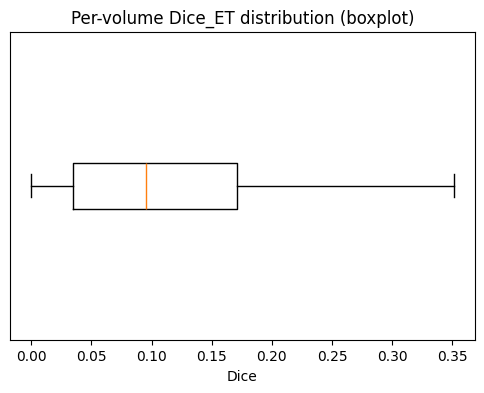


Top 5 worst volumes by Dice:


,volume,n_slices,gt_voxels,pred_voxels,dice,detected,gt_has
41,volume_264,33,8633,0,0.000000,False,True
69,volume_79,29,3676,0,0.000000,False,True
36,volume_234,76,47532,34236,0.001101,True,True
11,volume_141,44,12494,940,0.001191,True,True
45,volume_274,81,7382,27913,0.001643,True,True



Top 5 best volumes by Dice:


,volume,n_slices,gt_voxels,pred_voxels,dice,detected,gt_has
2,volume_112,79,100584,36687,0.351159,True,True
31,volume_220,75,87715,20735,0.341153,True,True
14,volume_146,60,66520,30683,0.320155,True,True
49,volume_2,55,51297,11902,0.299593,True,True
24,volume_196,72,122581,36622,0.295773,True,True


Wrote per-volume metrics to et_volume_metrics.csv


In [34]:
# Evaluation: volume-level ET metrics and reporting
from collections import defaultdict
import re
# Attempt to auto-load a Stage-B (ET) model from ./model_et.pth if available
model_et = None
et_weights = './model_et.pth'
if os.path.exists(et_weights):
    try:
        print('Found ET weights at', et_weights, '— loading...')
        model_et = smp.Unet(encoder_name='resnet18', encoder_weights=None, in_channels=1, classes=1, activation=None)
        state = torch.load(et_weights, map_location=DEVICE, weights_only=True)
        model_et.load_state_dict(state)
        model_et.to(DEVICE)
        model_et.eval()
        print('Loaded Stage-B model.')
    except Exception as e:
        print('Failed loading Stage-B model:', e)
else:
    print('No Stage-B model found at ./model_et.pth — evaluation will use empty ET predictions unless you provide a model.')

def slice_idx_from_name(fname):
    m = re.search(r'_slice_(\d+)', fname)
    return int(m.group(1)) if m else 0

def group_files_by_volume(file_list):
    vols = defaultdict(list)
    for f in file_list:
        vid = get_volume_id(f)
        vols[vid].append(f)
    # sort by slice index
    for k in vols:
        vols[k] = sorted(vols[k], key=slice_idx_from_name)
    return vols

# Run cascade_predict on each test slice and aggregate per-volume
test_vol_groups = group_files_by_volume(test_files)
results = []

for vol_id, files in tqdm(test_vol_groups.items(), desc='Evaluating volumes'):
    # allocate list of 2D arrays for GT and pred
    gt_stack = []
    pred_stack = []
    for fname in files:
        fullpath = os.path.join(DATA_DIR, fname)
        res = cascade_predict(fullpath, MODEL_WT, model_et=model_et, device=DEVICE)
        # et_prob_full is full slice sized (H,W)
        pred_map = res['et_prob_full'] if res.get('et_prob_full') is not None else np.zeros((128,128), dtype=np.float32)
        gt_map = res['gt_et_full'] if res.get('gt_et_full') is not None else np.zeros_like(pred_map)
        pred_stack.append((pred_map > 0.5).astype(np.uint8))
        gt_stack.append(gt_map.astype(np.uint8))
    if len(gt_stack) == 0:
        continue
    vol_pred = np.stack(pred_stack, axis=0)  # (Z,H,W)
    vol_gt = np.stack(gt_stack, axis=0)
    # flatten
    p = vol_pred.reshape(-1).astype(np.uint8)
    g = vol_gt.reshape(-1).astype(np.uint8)
    inter = int((p & g).sum())
    p_sum = int(p.sum())
    g_sum = int(g.sum())
    if p_sum + g_sum == 0:
        dice = 1.0
    else:
        dice = (2.0 * inter) / (p_sum + g_sum + 1e-7)
    detected = (p_sum > 0)
    gt_has = (g_sum > 0)
    results.append({'volume': vol_id, 'n_slices': len(files), 'gt_voxels': g_sum, 'pred_voxels': p_sum, 'dice': dice, 'detected': detected, 'gt_has': gt_has})

# Build DataFrame and report
df = pd.DataFrame(results)
# mean Dice across volumes (include all volumes):
mean_dice_all = df['dice'].mean()
# mean Dice only for volumes with GT ET
mean_dice_pos = df[df['gt_has']]['dice'].mean() if df['gt_has'].any() else float('nan')
# sensitivity/recall for ET presence detection: among volumes with GT ET, fraction where predicted any ET
if df['gt_has'].sum() > 0:
    recall = df[(df['gt_has']) & (df['detected'])].shape[0] / df[df['gt_has']].shape[0]
else:
    recall = float('nan')

print(f'Mean volume-level Dice (all volumes): {mean_dice_all:.4f}')
print(f'Mean volume-level Dice (GT-ET volumes only): {mean_dice_pos:.4f}')
print(f'Volume-level ET detection recall (sensitivity): {recall:.4f}')

# Show per-volume boxplot of dice distribution
plt.figure(figsize=(6,4))
plt.boxplot(df['dice'].values, vert=False)
plt.title('Per-volume Dice_ET distribution (boxplot)')
plt.xlabel('Dice')
plt.yticks([])
plt.show()

# Show table of worst/best volumes
print('\nTop 5 worst volumes by Dice:')
display(df.sort_values('dice').head(5))
print('\nTop 5 best volumes by Dice:')
display(df.sort_values('dice', ascending=False).head(5))

# Save per-volume CSV for downstream analysis
out_csv = 'et_volume_metrics.csv'
df.to_csv(out_csv, index=False)
print(f'Wrote per-volume metrics to {out_csv}')

In [35]:
# Ablation experiments: ROI / Normalization / Modalities / Loss
from itertools import product
import pandas as pd
import time

# Small helper losses: focal BCE and focal-Tversky
bce_loss_fn = torch.nn.BCEWithLogitsLoss()
def focal_bce_loss(logits, targets, alpha=0.25, gamma=2.0):
    probs = torch.sigmoid(logits)
    targets = targets.float()
    bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
    p_t = probs * targets + (1 - probs) * (1 - targets)
    loss = alpha * (1 - p_t) ** gamma * bce
    return loss.mean()

def focal_tversky_loss(logits, targets, alpha=0.7, beta=0.3, gamma=0.75, eps=1e-7):
    probs = torch.sigmoid(logits)
    targets = targets.float()
    dims = (1,2,3) if probs.ndim==4 else (1,2)
    TP = (probs * targets).sum(dim=dims)
    FP = (probs * (1 - targets)).sum(dim=dims)
    FN = ((1 - probs) * targets).sum(dim=dims)
    T = (TP + eps) / (TP + alpha * FN + beta * FP + eps)
    loss = (1 - T) ** gamma
    return loss.mean()

# Simple dice computation for binary masks (inputs: logits)
def compute_binary_dice_from_logits(logits, targets, thr=0.5, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs > thr).float()
    targets = targets.float()
    dims = (1,2,3) if preds.ndim==4 else (1,2)
    inter = (preds * targets).sum(dim=dims)
    denom = preds.sum(dim=dims) + targets.sum(dim=dims)
    dice = ((2.0 * inter) / (denom + eps)).mean().item()
    return dice

# Training wrapper for one experiment configuration
def run_ablation_experiment(cfg, epochs=3, train_subset=400, val_subset=200, device=DEVICE):
    print('Running', cfg)
    # Optionally disable normalization by monkeypatching `normalize_modality`
    global normalize_modality
    normalize_backup = normalize_modality
    if not cfg['normalization']:
        def _identity(arr, brain_mask, pct_clip=None, eps=1e-8):
            return arr.astype(np.float32)
        normalize_modality = _identity

    try:
        # Choose dataset class and ROI behaviour: use_gt_wt=True simulates ROIFromStageA (GT proxy)
        if cfg['roi']:
            ds_train_files = train_files[:min(train_subset, len(train_files))]
            ds_val_files = val_files[:min(val_subset, len(val_files))]
            train_ds = BraTSDatasetET(ds_train_files, DATA_DIR, use_gt_wt=True, input_modalities=cfg['modalities'], percentile_clip=(0.5,99.5) if cfg['normalization'] else None, et_channel=(ET_CH if 'ET_CH' in globals() else None))
            val_ds = BraTSDatasetET(ds_val_files, DATA_DIR, use_gt_wt=True, input_modalities=cfg['modalities'], percentile_clip=(0.5,99.5) if cfg['normalization'] else None, et_channel=(ET_CH if 'ET_CH' in globals() else None))
        else:
            # No ROI: use full-slice ET dataset with use_gt_wt=False (central crop fallback)
            ds_train_files = train_files[:min(train_subset, len(train_files))]
            ds_val_files = val_files[:min(val_subset, len(val_files))]
            train_ds = BraTSDatasetET(ds_train_files, DATA_DIR, use_gt_wt=False, input_modalities=cfg['modalities'], percentile_clip=(0.5,99.5) if cfg['normalization'] else None, et_channel=(ET_CH if 'ET_CH' in globals() else None))
            val_ds = BraTSDatasetET(ds_val_files, DATA_DIR, use_gt_wt=False, input_modalities=cfg['modalities'], percentile_clip=(0.5,99.5) if cfg['normalization'] else None, et_channel=(ET_CH if 'ET_CH' in globals() else None))

        train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0)
        val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0)

        # Small UNet model (resnet18 encoder). Use small model for quick runs.
        in_ch = len(cfg['modalities'])
        model = smp.Unet(encoder_name='resnet18', encoder_weights=None, in_channels=in_ch, classes=1, activation=None)
        model.to(device)
        opt = optim.Adam(model.parameters(), lr=1e-3)

        # Select loss function
        loss_name = cfg['loss']
        def loss_fn(logits, targets):
            targets = targets.float()
            if loss_name == 'dice':
                return smp.losses.DiceLoss(mode='binary', from_logits=True)(logits, targets.squeeze(1).float()) + torch.nn.BCEWithLogitsLoss()(logits, targets)
            elif loss_name == 'dice+focal':
                return smp.losses.DiceLoss(mode='binary', from_logits=True)(logits, targets.squeeze(1).float()) + focal_bce_loss(logits, targets)
            elif loss_name == 'focal-tversky':
                return focal_tversky_loss(logits, targets)
            else:
                return torch.nn.BCEWithLogitsLoss()(logits, targets)

        # Training loop (short)
        for ep in range(epochs):
            model.train()
            running = 0.0
            for xb, yb in train_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                opt.zero_grad()
                logits = model(xb)
                # ensure shape [N,1,H,W] for targets
                if yb.ndim==3:
                    yb = yb[:,None,...]
                loss = loss_fn(logits, yb)
                loss.backward()
                opt.step()
                running += float(loss.item())
            # simple val after each epoch (quiet)
        # Final evaluation on val set (slice-level dice focusing on ET-positive slices)
        model.eval()
        dices = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                if yb.ndim==3:
                    yb = yb[:,None,...]
                logits = model(xb)
                # compute per-batch dice only for samples with GT ET (>0)
                probs = torch.sigmoid(logits)
                preds = (probs > 0.5).float()
                gt = yb.float()
                # per-sample dice
                for i in range(preds.shape[0]):
                    g = gt[i]
                    if g.sum() == 0:
                        continue
                    p = preds[i]
                    inter = (p * g).sum()
                    denom = p.sum() + g.sum()
                    d = (2.0 * inter) / (denom + 1e-7)
                    dices.append(float(d))
        mean_dice = float('nan') if len(dices)==0 else sum(dices)/len(dices)
        print(f"Experiment result: mean_val_Dice_ET={mean_dice:.4f} (cfg={cfg})")
        return mean_dice
    finally:
        # restore normalization function
        normalize_modality = normalize_backup

# Build config grid
roi_options = [False, True]  # No ROI vs ROI-from-StageA (GT proxy)
norm_options = [False, True]  # No normalization vs z-score normalization (True)
modalities_options = [[ 't1ce' ], [ 't1ce', 'flair' ], [ 't1', 't1ce', 't2', 'flair' ]]
loss_options = [ 'dice', 'dice+focal', 'focal-tversky' ]

configs = []
for roi, norm, mods, loss_name in product(roi_options, norm_options, modalities_options, loss_options):
    configs.append({'roi': roi, 'normalization': norm, 'modalities': mods, 'loss': loss_name})

# Run experiments (short: 3 epochs each). Be mindful of time — consider reducing subsets if needed.
results = []
start_all = time.time()
for cfg in configs:
    try:
        val_dice = run_ablation_experiment(cfg, epochs=3)
    except Exception as e:
        print('Experiment failed', cfg, e)
        val_dice = float('nan')
    results.append({**cfg, 'mean_val_Dice_ET': val_dice})
    # quick checkpoint save after each experiment
    pd.DataFrame(results).to_csv('ablation_results_partial.csv', index=False)

end_all = time.time()
print(f'All experiments finished in {end_all-start_all:.1f}s — saving results to ablation_results.csv')
df_results = pd.DataFrame(results)
df_results.to_csv('ablation_results.csv', index=False)
df_results


Running {'roi': False, 'normalization': False, 'modalities': ['t1ce'], 'loss': 'dice'}
Experiment result: mean_val_Dice_ET=0.0444 (cfg={'roi': False, 'normalization': False, 'modalities': ['t1ce'], 'loss': 'dice'})
Running {'roi': False, 'normalization': False, 'modalities': ['t1ce'], 'loss': 'dice+focal'}
Experiment result: mean_val_Dice_ET=0.0390 (cfg={'roi': False, 'normalization': False, 'modalities': ['t1ce'], 'loss': 'dice+focal'})
Running {'roi': False, 'normalization': False, 'modalities': ['t1ce'], 'loss': 'focal-tversky'}
Experiment result: mean_val_Dice_ET=0.2541 (cfg={'roi': False, 'normalization': False, 'modalities': ['t1ce'], 'loss': 'focal-tversky'})
Running {'roi': False, 'normalization': False, 'modalities': ['t1ce', 'flair'], 'loss': 'dice'}
Experiment result: mean_val_Dice_ET=0.0644 (cfg={'roi': False, 'normalization': False, 'modalities': ['t1ce', 'flair'], 'loss': 'dice'})
Running {'roi': False, 'normalization': False, 'modalities': ['t1ce', 'flair'], 'loss': 'dic

KeyboardInterrupt: 